# import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [13]:
df = pd.read_csv('US_GOLD_PRICE_CSV.csv')

In [14]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [15]:
"""
1. SPX – S&P 500 Index
Meaning: The SPX is a stock market index that tracks the 500 largest publicly traded companies in the U.S.

In relation to gold: Often used as a benchmark for the equity market. Gold tends to have an inverse relationship with the SPX during times of economic uncertainty — when stocks fall, gold can rise as a "safe haven."

2. GLD – SPDR Gold Shares ETF
Meaning: An exchange-traded fund that tracks the price of gold bullion.

In relation to gold: Directly tied to gold prices. Buying GLD is essentially like investing in physical gold without owning it physically.

3. USO – United States Oil Fund
Meaning: An ETF that tracks the price of crude oil.

In relation to gold: While not directly tied to gold, oil and gold are both commodities and are sometimes used together in analysis of inflation, commodity cycles, or macroeconomic trends.

4. SLV – iShares Silver Trust
Meaning: An ETF that tracks the price of silver.

In relation to gold: Silver often trades in correlation with gold. Analysts sometimes use the gold-to-silver ratio (GLD/SLV) to assess relative value between the two precious metals.
"""

'\n1. SPX – S&P 500 Index\nMeaning: The SPX is a stock market index that tracks the 500 largest publicly traded companies in the U.S.\n\nIn relation to gold: Often used as a benchmark for the equity market. Gold tends to have an inverse relationship with the SPX during times of economic uncertainty — when stocks fall, gold can rise as a "safe haven."\n\n2. GLD – SPDR Gold Shares ETF\nMeaning: An exchange-traded fund that tracks the price of gold bullion.\n\nIn relation to gold: Directly tied to gold prices. Buying GLD is essentially like investing in physical gold without owning it physically.\n\n3. USO – United States Oil Fund\nMeaning: An ETF that tracks the price of crude oil.\n\nIn relation to gold: While not directly tied to gold, oil and gold are both commodities and are sometimes used together in analysis of inflation, commodity cycles, or macroeconomic trends.\n\n4. SLV – iShares Silver Trust\nMeaning: An ETF that tracks the price of silver.\n\nIn relation to gold: Silver often

In [32]:
#We need to focus only on 'GLD' Column (Output)
df = df.drop(['Date'],axis=1)

In [33]:
#shape
df.shape

(2286, 5)

In [34]:
#To check the datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2286 entries, 0 to 2285
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SPX      2286 non-null   float64
 1   GLD      2286 non-null   float64
 2   USO      2286 non-null   float64
 3   SLV      2286 non-null   float64
 4   EUR/USD  2286 non-null   float64
dtypes: float64(5)
memory usage: 107.2 KB


In [35]:
#Here. data is object. anyhow we no need this. hence remove
df.tail()


,SPX,GLD,USO,SLV,EUR/USD
2281,2654.800049,123.709999,13.61,15.24,1.199156
2282,2635.669922,123.650002,13.67,15.42,1.195100
2283,2629.729980,124.279999,13.82,15.46,1.198926
2284,2672.629883,124.570000,14.10,15.52,1.193374
2285,2671.919922,124.589996,14.06,15.51,1.186789


In [36]:
#To check the missing/Null values
df.isnull().sum()

SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [37]:
df = df.dropna()

In [38]:
df.isnull().sum()

SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [39]:
#To fetch statistical data
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000
mean,1652.452475,122.730420,31.872756,20.092895,1.283821
std,517.648256,23.303606,19.526929,7.096253,0.131601
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1238.350006,109.720001,14.382500,15.570000,1.169458
50%,1547.070007,120.559998,33.875000,17.280000,1.303424
75%,2071.440002,132.864998,37.830002,22.972500,1.370121
max,2872.870117,184.589996,117.480003,47.259998,1.598798


# Correlation:

#### Positive correlation
#### Negative correlation

In [40]:
correlation = df.corr()

<AxesSubplot:>

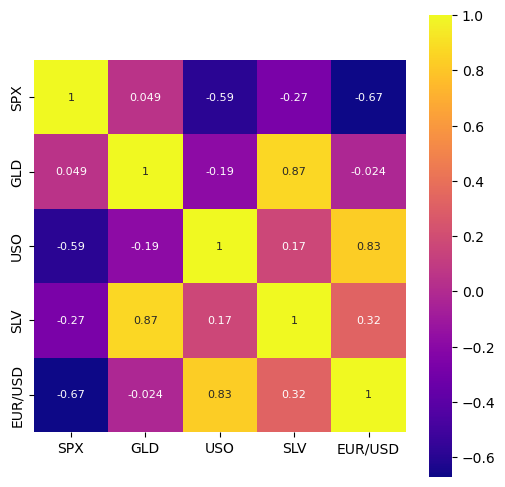

In [41]:
plt.figure(figsize=(6,6))
sns.heatmap(correlation,cbar=True,square=True, annot=True, annot_kws={"size":8}, cmap="plasma")

In [42]:
print(correlation['GLD'])

SPX        0.049311
GLD        1.000000
USO       -0.186397
SLV        0.867010
EUR/USD   -0.024312
Name: GLD, dtype: float64


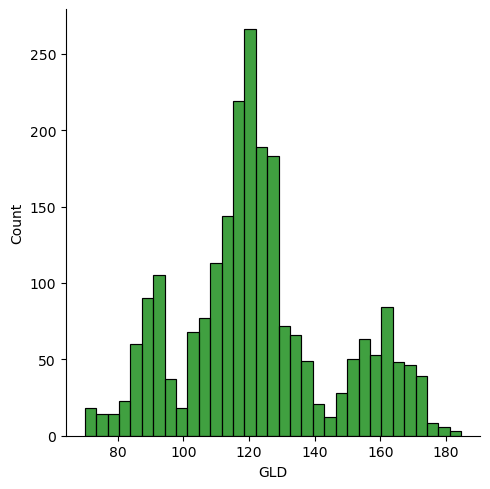

In [43]:
#To check the distribution of the GLD Price
sns.displot(df['GLD'],color='green')

# Training ans Testing

In [46]:
#split into x and y axis
X = df.drop(['GLD'], axis=1)
y = df['GLD']

In [47]:
X.shape

(2286, 4)

In [48]:
y.shape

(2286,)

In [49]:
#Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [50]:
X_train.shape

(1828, 4)

In [51]:
X_test.shape

(458, 4)

# Train Model

In [52]:
from sklearn.ensemble import RandomForestRegressor

In [53]:
reg = RandomForestRegressor()
reg.fit(X_train,y_train)

RandomForestRegressor()

In [54]:
#predict for text set
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.9905461191910139